# Applying the federated model to SDY1737

SDY1737 does not carry the full four-feature set, so it joins the federation on
the features it shares with the other institutions: **weight_kg, GAD65, Sex**.
It drops received_active_treatment (its ImmPort arms are age groups, Adult / Pediatric, with no treatment/placebo distinction).

The other institutions (SDY524 and SDY569) refit on this shared subset and send
their coefficient vectors. SDY1737 combines them (sample-size-weighted mean) and
applies the result to its own subjects. SDY1737's subject-level data never
leaves; only the partners' coefficient vectors arrive.



## 1. Setup

In [1]:
from __future__ import annotations
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

REPO = Path.cwd()
if (REPO / "src").exists():
    sys.path.insert(0, str(REPO / "src"))
elif (REPO.parent / "src").exists():
    REPO = REPO.parent
    sys.path.insert(0, str(REPO / "src"))
os.chdir(REPO)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold

import oadr_data as od

RNG_SEED = 42
N_TREES = 200
np.random.seed(RNG_SEED)
(REPO / "figures").mkdir(exist_ok=True)
print("Repo root:", REPO)


Repo root: /Users/adeslatt/Scitechcon Dropbox/Anne DeslattesMays/projects/oadr-autoantibody


## 2. Assemble SDY1737 and the partners on the shared features

Each study's shared features are pulled from the source that has them. `weight_kg`
comes from the extended panel; `GAD65` and `Sex` from the autoantibody panel;
`received_active_treatment` by transitive closure over the ImmPort arm files.
The target is log(C-peptide AUC).


In [2]:
FEATS = ['weight_kg', 'GAD65', 'Sex']
PARTNERS = ["SDY524", "SDY569"]
THIS = "SDY1737"

def assemble(study, feats):
    """Return (X, y) for `study` on `feats`, drawing each feature from the
    source that carries it for that study."""
    if "weight_kg" in feats:                       # needs the extended panel
        b = od.load_panel_b(study)
        for c in ("bmi", "height_cm", "weight_kg"):
            b[c] = b[c].fillna(b[c].median())
        bad = b["height_cm"] <= 0
        b.loc[bad, "height_cm"] = np.sqrt(b.loc[bad, "weight_kg"] / b.loc[bad, "bmi"]) * 100
        return b[feats].values.astype(float), b["log_auc"].values.astype(float)
    a = od.load_panel_a(study)                      # GAD65, Sex available for all studies
    if "received_active_treatment" in feats:
        a = a.assign(received_active_treatment=od._treatment_from_arms(study, a["Subject_ID"]).values)
    return a[feats].values.astype(float), a[od.PANEL_A_TARGET].values.astype(float)

Xt, yt = assemble(THIS, FEATS)
print(f"{THIS}: N={len(yt)}, features={FEATS}")
for p in PARTNERS:
    Xp, yp = assemble(p, FEATS)
    print(f"  partner {p}: N={len(yp)}")


SDY1737: N=16, features=['weight_kg', 'GAD65', 'Sex']
  partner SDY524: N=72
  partner SDY569: N=10


## 3. Solo vs federated — three methods

**Solo**: SDY1737 predicts its held-out subjects with a model fit on its own
training rows (5-fold CV). **Federated**: the partners fit on the same shared
features, their vectors (or forests, for Random Forest) are combined, and that
model predicts SDY1737's held-out subjects. For the linear methods the
combination is a sample-size-weighted mean of coefficients; for Random Forest it
is the Union-of-Forests (predictions averaged).


In [3]:
def partner_linear(model_fn):
    vecs = []
    for p in PARTNERS:
        Xp, yp = assemble(p, FEATS)
        sc = MinMaxScaler().fit(Xp)
        m = model_fn().fit(sc.transform(Xp), yp)
        vecs.append((m.coef_, m.intercept_, len(yp)))
    return vecs

def partner_forests():
    fs = []
    for p in PARTNERS:
        Xp, yp = assemble(p, FEATS)
        sc = MinMaxScaler().fit(Xp)
        f = RandomForestRegressor(n_estimators=N_TREES, min_samples_leaf=2,
                                  n_jobs=1, random_state=RNG_SEED).fit(sc.transform(Xp), yp)
        fs.append((f, sc))
    return fs

def _r2(y, p):
    rss = np.sum((y - p) ** 2); tss = np.sum((y - y.mean()) ** 2)
    return 1 - rss / tss if tss > 0 else float("nan")

def run(method_name, model_fn, kind):
    kf = KFold(min(5, max(2, len(yt) // 2)), shuffle=True, random_state=RNG_SEED)
    solo = np.full(len(yt), np.nan); fed = np.full(len(yt), np.nan)
    plinear = partner_linear(model_fn) if kind == "linear" else None
    pforests = partner_forests() if kind == "forest" else None
    for tr, te in kf.split(Xt):
        sc = MinMaxScaler().fit(Xt[tr])
        m = model_fn().fit(sc.transform(Xt[tr]), yt[tr])
        solo[te] = m.predict(sc.transform(Xt[te]))
        if kind == "linear":
            vecs = [(m.coef_, m.intercept_, len(tr))] + plinear
            coefs = np.stack([v[0] for v in vecs]); ints = np.array([v[1] for v in vecs])
            sizes = np.array([v[2] for v in vecs])
            ac = np.average(coefs, axis=0, weights=sizes); ai = np.average(ints, weights=sizes)
            fed[te] = sc.transform(Xt[te]) @ ac + ai
        else:
            preds = [m.predict(sc.transform(Xt[te]))]
            for f, scp in pforests:
                preds.append(f.predict(scp.transform(Xt[te])))
            fed[te] = np.mean(preds, axis=0)
    return solo, fed, _r2(yt, solo), _r2(yt, fed)

METHODS = [
    ("MLR (Ridge)", lambda: Ridge(alpha=1.0), "linear"),
    ("LASSO", lambda: Lasso(alpha=0.008, max_iter=50000), "linear"),
    ("Random Forest", lambda: RandomForestRegressor(n_estimators=N_TREES, min_samples_leaf=2,
                                                     n_jobs=1, random_state=RNG_SEED), "forest"),
]
results = {}
for name, fn, kind in METHODS:
    solo, fed, r2s, r2f = run(name, fn, kind)
    results[name] = (solo, fed, r2s, r2f)
    print(f"{name:14s}  solo R2 = {r2s:+.3f}   federated R2 = {r2f:+.3f}   "
          f"({'improves' if r2f > r2s else 'no gain'})")


MLR (Ridge)     solo R2 = -0.296   federated R2 = -0.579   (no gain)
LASSO           solo R2 = -0.559   federated R2 = -0.701   (no gain)
Random Forest   solo R2 = -0.213   federated R2 = -0.167   (improves)


## 4. Scatter — SDY1737 alone vs SDY1737 + partners, per method

Observed vs predicted log(C-peptide AUC) for SDY1737's held-out subjects.


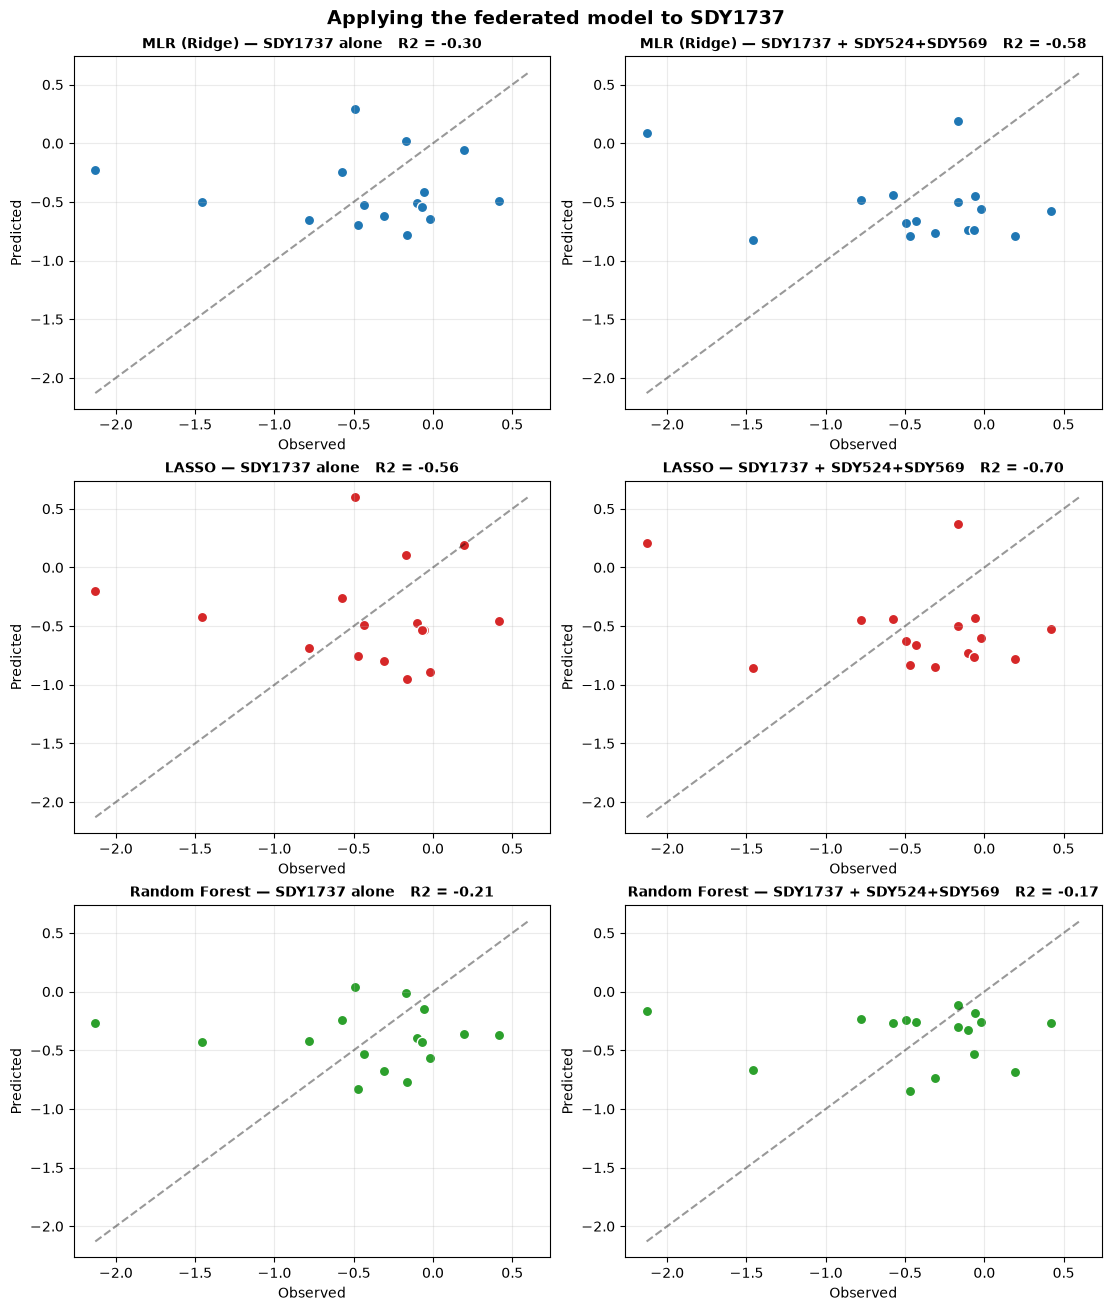

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(11, 13), constrained_layout=True)
colors = {"MLR (Ridge)": "#1f77b4", "LASSO": "#d62728", "Random Forest": "#2ca02c"}
lo = min(yt.min(), min(np.nanmin(results[m][0]) for m in results),
         min(np.nanmin(results[m][1]) for m in results))
hi = max(yt.max(), max(np.nanmax(results[m][0]) for m in results),
         max(np.nanmax(results[m][1]) for m in results))
for row, (name, _, _) in enumerate(METHODS):
    solo, fed, r2s, r2f = results[name]
    for col, (pred, lab, r2v) in enumerate([(solo, THIS + " alone", r2s),
                                            (fed, THIS + " + " + "+".join(PARTNERS), r2f)]):
        ax = axes[row][col]
        ax.scatter(yt, pred, c=colors[name], s=55, edgecolor="white")
        ax.plot([lo, hi], [lo, hi], "k--", alpha=0.4)
        ax.set_title(f"{name} — {lab}   R2 = {r2v:+.2f}", fontweight="bold", fontsize=10)
        ax.set_xlabel("Observed"); ax.set_ylabel("Predicted"); ax.grid(alpha=0.25)
fig.suptitle("Applying the federated model to " + THIS, fontsize=14, fontweight="bold")
fig.savefig("figures/apply_coefficients_" + THIS + ".pdf", dpi=300)
fig.savefig("figures/apply_coefficients_" + THIS + ".png", dpi=220)
plt.show()


## 5. Why federation does not help SDY1737

SDY1737 is the Aralast trial (alpha-1 antitrypsin) — a different intervention from the anti-CD3 antibody trials the partners (SDY524, SDY569) come from. It keeps weight_kg, GAD65, and Sex, but the relationship between those features and residual C-peptide differs in this population, so the partners' coefficients do not transfer: the federated R² is lower than solo for the linear methods. This is why SDY1737 is excluded from the federated headline model.


## 6. Outputs

- `figures/apply_coefficients_SDY1737.pdf` / `.png` — solo vs federated scatter
  for MLR, LASSO, and Random Forest.

This shows what SDY1737 gains by applying the other institutions' coefficients
on the features it shares with them — without contributing its own data to
their training, and without the feature it lacks.
